# Opinion Network Formation — Assignment 1

**Course:** Dynamical Processes in Complex Networks

This notebook implements the full analysis pipeline from data preprocessing to network simulation. Running this notebook from top to bottom will automatically generate and save all the required visualizations (`.png` and `.gif` files) into this directory.

1. **Data Preprocessing** — Likert-to-numerical mapping
2. **Topic Opinion Scores** — Visualizing average agreement per topic
3. **TF-IDF Weighted Similarity Network** — Rare opinions create stronger ties
4. **Community Detection** — Louvain algorithm finds ideological clusters
5. **Centrality Metrics** — Identifying opinion influencers and brokers
6. **Multiplex Network** — Cross-topic ideological alignment
7. **Opinion Dynamics Simulation** — Deffuant Bounded Confidence Model
8. **Animation** — Generating a GIF of opinion dynamics


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
import community as community_louvain
import warnings, math

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.grid': True, 'grid.alpha': 0.3})


## 1. Data Preprocessing

Load the survey data and map categorical Likert responses to integer values.
The scale used: `Strongly Disagree → -2`, `Disagree → -1`, `Neutral → 0`, `Agree → +1`, `Strongly Agree → +2`.
`No Comments` is treated as neutral (0).


In [2]:
df = pd.read_csv('dataset.csv')
id_col = df.columns[0]
df.set_index(id_col, inplace=True)

mapping = {
    'Strongly Disagree': -2,
    'Disagree': -1,
    'Neutral': 0,
    'Agree': 1,
    'Strongly Agree': 2,
    'No Comments': 0
}
df_numeric = df.replace(mapping)
for col in df_numeric.columns:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0)

student_ids = df_numeric.index.tolist()
print(f"Students: {len(student_ids)}, Questions: {df_numeric.shape[1]}")

df_numeric.head()


Students: 96, Questions: 60


,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.,T07. Robots should replace humans in hazardous occupations whenever possible.,T08. AI-assisted diagnosis should become routine in healthcare.,T09. Autonomous vehicles will ultimately make transportation safer.,T10. Protection of personal data is more important than technological convenience.,...,"V06. Water conservation should be a priority in households, institutions, and industries.",V07. Protecting biodiversity is essential for long-term human well-being.,V08. Universities should adopt environmentally sustainable campus practices even if implementation costs increase.,"V09. Products should be designed to encourage reuse, repair, and recycling.",V10. Consumers should consider environmental impact when purchasing products.,V11. Technological innovation is essential for addressing environmental challenges.,V12. Environmental sustainability should be integrated into higher education curricula.,V13. Companies should be held accountable for the environmental impacts of their activities.,V14. International cooperation is necessary to effectively address environmental challenges.,V15. Current generations have a responsibility to protect natural resources for future generations.
id. Response ID,,,,,,,,,,,,,,,,,,,,,
11,1.0,1.0,0.0,2.0,2.0,1.0,1.0,-1.0,0.0,1.0,...,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0
12,1.0,1.0,2.0,1.0,0.0,1.0,1.0,-1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
13,1.0,2.0,0.0,-1.0,2.0,1.0,2.0,1.0,0.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0
14,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,-1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0
16,0.0,1.0,2.0,2.0,-2.0,2.0,2.0,1.0,0.0,2.0,...,1.0,2.0,1.0,2.0,0.0,1.0,0.0,2.0,2.0,1.0


## 2. Topic Opinion Scores

Before building the network, let's visualize the average opinion score across all 60 questions, grouped by the 4 overarching topics (Technology, Education, Society, Environment).


Saved: topic_scores.png


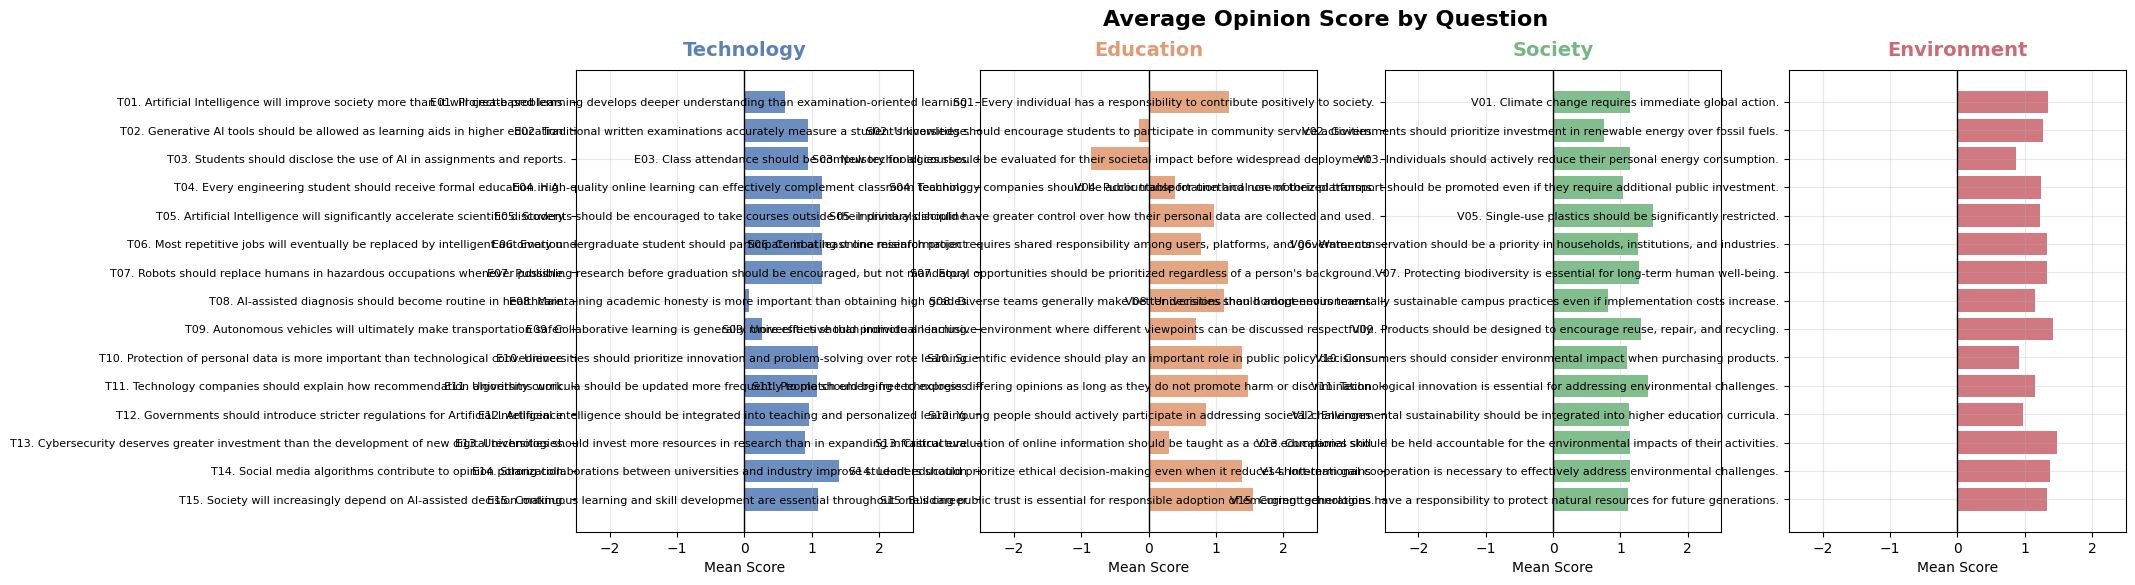

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)

topics = {
    'Technology':  ([c for c in df_numeric.columns if c.startswith('T')], '#5C81B8'),
    'Education':   ([c for c in df_numeric.columns if c.startswith('E')], '#E09B74'),
    'Society':     ([c for c in df_numeric.columns if c.startswith('S')], '#75B682'),
    'Environment': ([c for c in df_numeric.columns if c.startswith('V')], '#CC6B73')
}

for ax, (topic_name, (cols, color)) in zip(axes, topics.items()):
    scores = df_numeric[cols].mean()
    y_pos = np.arange(len(cols))
    ax.barh(y_pos, scores, color=color, alpha=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cols, fontsize=8)
    ax.set_xlim(-2.5, 2.5)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(topic_name, fontsize=14, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Mean Score', fontsize=10)
    ax.invert_yaxis()

plt.suptitle('Average Opinion Score by Question', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_scores.png', dpi=200, bbox_inches='tight')
print("Saved: topic_scores.png")
plt.show()


## 3. TF-IDF Weighted Similarity Network

Each student is treated as a "document" and their responses as "terms."
TF-IDF down-weights universally-agreed opinions and up-weights rare, distinguishing ones.
We connect students whose TF-IDF cosine similarity is in the top 30% (70th percentile threshold).


In [4]:
# Shift to positive range for TF-IDF
df_shifted = df_numeric + 3

tfidf = TfidfTransformer()
tfidf_matrix = tfidf.fit_transform(df_shifted.values)
similarity_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(similarity_matrix, 0)

upper_vals = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
threshold = np.percentile(upper_vals, 70)
print(f"Edge threshold (70th percentile): {threshold:.4f}")

G_tfidf = nx.Graph()
for student in student_ids:
    G_tfidf.add_node(student)

for i in range(len(student_ids)):
    for j in range(i + 1, len(student_ids)):
        if similarity_matrix[i, j] > threshold:
            G_tfidf.add_edge(student_ids[i], student_ids[j], weight=similarity_matrix[i, j])

print(f"\nNetwork: {G_tfidf.number_of_nodes()} nodes, {G_tfidf.number_of_edges()} edges")
print(f"Density: {nx.density(G_tfidf):.4f}")
print(f"Connected Components: {nx.number_connected_components(G_tfidf)}")


Edge threshold (70th percentile): 0.9751

Network: 96 nodes, 1368 edges
Density: 0.3000
Connected Components: 11


## 4. Community Detection & Centrality

We apply the **Louvain algorithm** to detect ideological communities.
We measure:
- **Degree Centrality** — who shares the most links (broadest connectors)
- **Betweenness Centrality** — who bridges different communities (brokers)


In [5]:
# Community detection
partition = community_louvain.best_partition(G_tfidf, weight='weight', random_state=42)
num_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G_tfidf, weight='weight')
print(f"Communities: {num_communities} | Modularity Q: {modularity:.4f}")

# Centrality metrics
centrality_degree = nx.degree_centrality(G_tfidf)
centrality_between = nx.betweenness_centrality(G_tfidf, weight='weight')
top_between_node = sorted(centrality_between.items(), key=lambda x: x[1], reverse=True)[0][0]

print("\nTop 5 — Degree Centrality:")
for n, c in sorted(centrality_degree.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Student {n}: {c:.4f}")

print("\nTop 5 — Betweenness Centrality:")
for n, c in sorted(centrality_between.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  Student {n}: {c:.4f}")


Communities: 13 | Modularity Q: 0.1059

Top 5 — Degree Centrality:
  Student 44: 0.7368
  Student 60: 0.7368
  Student 68: 0.7368
  Student 73: 0.7368
  Student 78: 0.7368

Top 5 — Betweenness Centrality:
  Student 67: 0.0533
  Student 14: 0.0249
  Student 77: 0.0242
  Student 97: 0.0237
  Student 41: 0.0235


## 5. Network Visualization

A custom layout that places the 3 largest communities in a triangle, with outliers scattered around the edges.
Node **color** = Louvain community. Node **size** = degree centrality.
Gold ring = highest betweenness node (the key opinion broker).


Saved: opinion_network.png


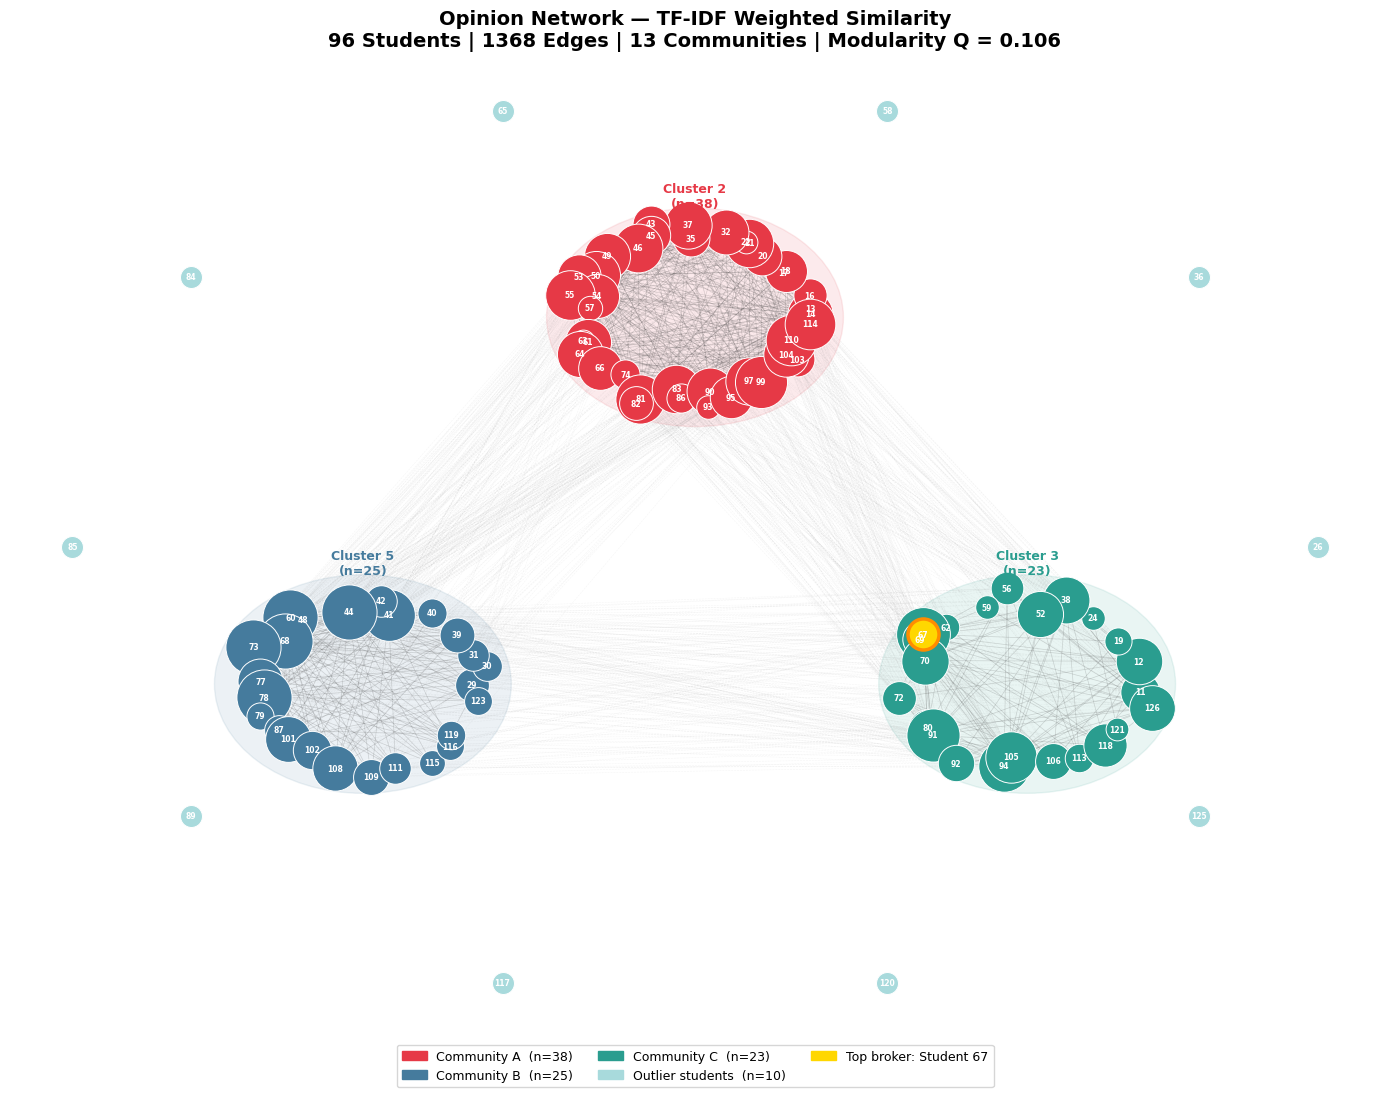

In [6]:
# Find the 3 main communities and separate outliers
comm_sizes = {}
for n, c in partition.items():
    comm_sizes[c] = comm_sizes.get(c, 0) + 1
sorted_comms = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)

main_comms = {c for c, size in sorted_comms[:3]}
outlier_comms = {c for c, size in sorted_comms[3:]}

fig, ax = plt.subplots(figsize=(14, 11))

CMAP = {
    sorted_comms[0][0]: '#E63946',   # red - largest
    sorted_comms[1][0]: '#457B9D',   # blue - second
    sorted_comms[2][0]: '#2A9D8F',   # teal - third
}
DEFAULT_COLOR = '#A8DADC'

cluster_centers = {
    sorted_comms[0][0]: np.array([0.0, 1.5]),
    sorted_comms[1][0]: np.array([-1.6, -0.9]),
    sorted_comms[2][0]: np.array([1.6, -0.9]),
}
RADIUS = 0.55

pos = {}
for comm, center in cluster_centers.items():
    members = [n for n, c in partition.items() if c == comm]
    n = len(members)
    for i, node in enumerate(members):
        angle = 2 * math.pi * i / n
        offset = np.array([RADIUS * math.cos(angle), RADIUS * math.sin(angle)])
        jitter = np.random.RandomState(hash(str(node)) % 2**32).uniform(-0.08, 0.08, 2)
        pos[node] = center + offset + jitter

outlier_nodes = [n for n, c in partition.items() if c in outlier_comms]
for i, node in enumerate(outlier_nodes):
    angle = 2 * math.pi * i / max(len(outlier_nodes), 1)
    pos[node] = np.array([3.0 * math.cos(angle), 3.0 * math.sin(angle)])

inter_edges = [(u, v) for u, v in G_tfidf.edges() if partition[u] != partition[v]]
intra_edges  = [(u, v) for u, v in G_tfidf.edges() if partition[u] == partition[v]]

nx.draw_networkx_edges(G_tfidf, pos, edgelist=intra_edges, alpha=0.18, width=0.5, edge_color='#333333', ax=ax)
nx.draw_networkx_edges(G_tfidf, pos, edgelist=inter_edges, alpha=0.08, width=0.4, edge_color='#888888', style='dashed', ax=ax)

for node in G_tfidf.nodes():
    comm = partition[node]
    color = CMAP.get(comm, DEFAULT_COLOR)
    size = 250 + centrality_degree[node] * 1800
    nx.draw_networkx_nodes(G_tfidf, pos, nodelist=[node], node_color=color, node_size=size, edgecolors='white', linewidths=0.7, ax=ax)

nx.draw_networkx_nodes(G_tfidf, pos, nodelist=[top_between_node], node_color='gold', node_size=500, edgecolors='darkorange', linewidths=2.5, ax=ax)
nx.draw_networkx_labels(G_tfidf, pos, font_size=5.5, font_color='white', font_weight='bold', ax=ax)

from matplotlib.patches import Ellipse
for comm, center in cluster_centers.items():
    members = [n for n, c in partition.items() if c == comm]
    color = CMAP[comm]
    size = comm_sizes[comm]
    ellipse = Ellipse(xy=center, width=RADIUS*2.6, height=RADIUS*2.6, alpha=0.10, color=color, zorder=0)
    ax.add_patch(ellipse)
    ax.text(center[0], center[1] + RADIUS + 0.15, f'Cluster {sorted_comms[list(cluster_centers.keys()).index(comm)][0]+1}\n(n={size})',
            ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#E63946', label=f'Community A  (n={sorted_comms[0][1]})'),
    mpatches.Patch(color='#457B9D', label=f'Community B  (n={sorted_comms[1][1]})'),
    mpatches.Patch(color='#2A9D8F', label=f'Community C  (n={sorted_comms[2][1]})'),
    mpatches.Patch(color='#A8DADC', label=f'Outlier students  (n={len(outlier_nodes)})'),
    mpatches.Patch(color='gold',    label=f'Top broker: Student {top_between_node}'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.07), frameon=True)

ax.set_title(
    f'Opinion Network — TF-IDF Weighted Similarity\n'
    f'{G_tfidf.number_of_nodes()} Students | {G_tfidf.number_of_edges()} Edges | {num_communities} Communities | Modularity Q = {modularity:.3f}',
    fontsize=14, fontweight='bold', pad=15
)
ax.axis('off')
plt.tight_layout()
plt.savefig('opinion_network.png', dpi=200, bbox_inches='tight')
print("Saved: opinion_network.png")
plt.show()


## 6. Multiplex Network Analysis

We build one separate network per topic (4 layers). The **Jaccard edge overlap** between any two layers reveals how correlated opinions are *across* topics. A Jaccard of 1.0 = identical edge structure; 0.0 = completely independent.


Saved: multiplex_overlap.png


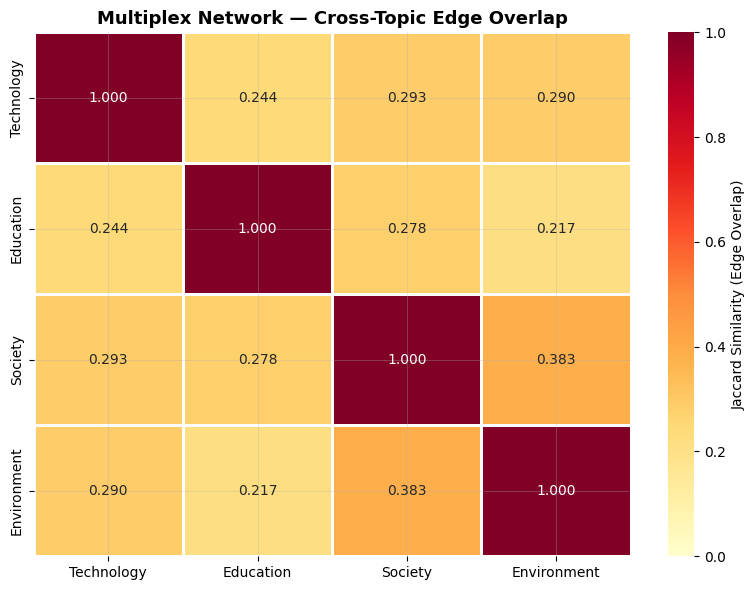

In [7]:
topics = {
    'Technology': [c for c in df_numeric.columns if c.startswith('T')],
    'Education':  [c for c in df_numeric.columns if c.startswith('E')],
    'Society':    [c for c in df_numeric.columns if c.startswith('S')],
    'Environment':[c for c in df_numeric.columns if c.startswith('V')]
}

layers = {}
for topic, cols in topics.items():
    layer_data = df_numeric[cols] + 3
    layer_sim = cosine_similarity(TfidfTransformer().fit_transform(layer_data.values))
    G_layer = nx.Graph()
    G_layer.add_nodes_from(student_ids)
    thr = np.percentile(layer_sim[np.triu_indices_from(layer_sim, k=1)], 70)
    for i in range(len(student_ids)):
        for j in range(i + 1, len(student_ids)):
            if layer_sim[i, j] > thr:
                G_layer.add_edge(student_ids[i], student_ids[j], weight=layer_sim[i, j])
    layers[topic] = G_layer

def edge_overlap(G1, G2):
    e1 = set(tuple(sorted(e)) for e in G1.edges())
    e2 = set(tuple(sorted(e)) for e in G2.edges())
    return len(e1 & e2) / len(e1 | e2) if e1 | e2 else 0

topic_names = list(topics.keys())
overlap_matrix = np.array([[edge_overlap(layers[a], layers[b]) for b in topic_names] for a in topic_names])

plt.figure(figsize=(8, 6))
sns.heatmap(overlap_matrix, annot=True, fmt='.3f', xticklabels=topic_names, yticklabels=topic_names,
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=1,
            cbar_kws={'label': 'Jaccard Similarity (Edge Overlap)'})
plt.title('Multiplex Network — Cross-Topic Edge Overlap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multiplex_overlap.png', dpi=200, bbox_inches='tight')
print("Saved: multiplex_overlap.png")
plt.show()


## 7. Opinion Dynamics — Deffuant Model

**Model parameters:**
- $\mu = 0.3$ (convergence rate)
- $\varepsilon = 0.5$ (bounded confidence threshold)
- **8,000 simulation steps**

Initial opinion per student = their average score across all 60 questions (∈ [−2, +2]).


Distinct final opinion clusters: 8 — sizes: [1, 11, 5, 1, 3, 1, 2, 72]


Saved: opinion_dynamics.png


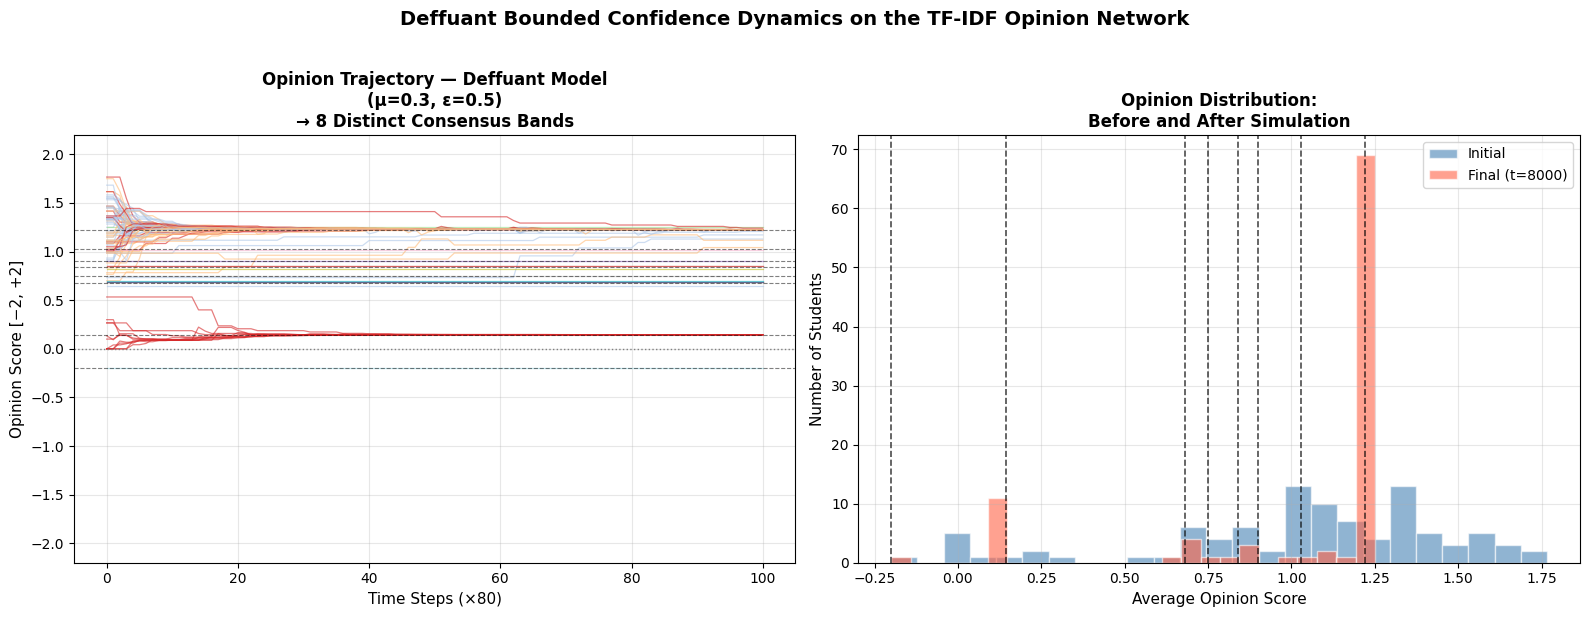

In [8]:
initial_opinions = df_numeric.mean(axis=1).to_dict()
mu = 0.3
epsilon = 0.5 
iterations = 8000
RECORD_EVERY = 80

current_opinions = dict(initial_opinions)
history = {n: [initial_opinions[n]] for n in G_tfidf.nodes()}
edges = list(G_tfidf.edges())

np.random.seed(42)
for t in range(iterations):
    if not edges: break
    u, v = edges[np.random.randint(len(edges))]
    ou, ov = current_opinions[u], current_opinions[v]
    if abs(ou - ov) < epsilon:
        current_opinions[u] = ou + mu * (ov - ou)
        current_opinions[v] = ov + mu * (ou - ov)
    if t % RECORD_EVERY == 0:
        for n in G_tfidf.nodes():
            history[n].append(current_opinions[n])

final_opinions = [current_opinions[n] for n in G_tfidf.nodes()]
initial_vals   = [initial_opinions[n] for n in G_tfidf.nodes()]

# Count distinct final clusters (opinions within 0.05 of each other)
sorted_finals = sorted(final_opinions)
clusters = []
current_cluster = [sorted_finals[0]]
for v in sorted_finals[1:]:
    if v - current_cluster[-1] < 0.05:
        current_cluster.append(v)
    else:
        clusters.append(current_cluster)
        current_cluster = [v]
clusters.append(current_cluster)
print(f"Distinct final opinion clusters: {len(clusters)} — sizes: {[len(c) for c in clusters]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
cmap_dyn = plt.cm.get_cmap('tab20', num_communities)
timesteps = range(len(history[student_ids[0]]))
for node in G_tfidf.nodes():
    color = cmap_dyn(partition[node] / num_communities)
    ax.plot(timesteps, history[node], color=color, alpha=0.6, linewidth=0.9)

for cl in clusters:
    ax.axhline(np.mean(cl), color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel(f'Time Steps (×{RECORD_EVERY})', fontsize=11)
ax.set_ylabel('Opinion Score [−2, +2]', fontsize=11)
ax.set_title(f'Opinion Trajectory — Deffuant Model\n(μ={mu}, ε={epsilon})\n→ {len(clusters)} Distinct Consensus Bands', fontsize=12, fontweight='bold')
ax.set_ylim(-2.2, 2.2)

ax2 = axes[1]
ax2.hist(initial_vals,   bins=25, alpha=0.6, color='steelblue', label='Initial', edgecolor='white')
ax2.hist(final_opinions, bins=25, alpha=0.6, color='tomato',    label=f'Final (t={iterations})', edgecolor='white')
for cl in clusters:
    ax2.axvline(np.mean(cl), color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('Average Opinion Score', fontsize=11)
ax2.set_ylabel('Number of Students', fontsize=11)
ax2.set_title('Opinion Distribution:\nBefore and After Simulation', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle(f'Deffuant Bounded Confidence Dynamics on the TF-IDF Opinion Network',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('opinion_dynamics.png', dpi=200, bbox_inches='tight')
print("Saved: opinion_dynamics.png")
plt.show()


## 8. Opinion Dynamics Animation (GIF)

Generates `opinion_dynamics.gif` showing how opinions spread across the network. Nodes change color based on their opinion score (Red = Disagree, Green = Agree). The top broker is highlighted with a gold ring.


In [9]:
# Setup a new simulation just for the animation snapshots (fewer frames for faster rendering)
GIF_STEPS = 5000
GIF_RECORD = 250

current_opinions = dict(initial_opinions)
snapshots = {0: dict(initial_opinions)}
edges_list = list(G_tfidf.edges())

np.random.seed(42)
for t in range(1, GIF_STEPS + 1):
    if not edges_list: break
    u, v = edges_list[np.random.randint(len(edges_list))]
    ou, ov = current_opinions[u], current_opinions[v]
    if abs(ou - ov) < epsilon:
        current_opinions[u] = ou + mu * (ov - ou)
        current_opinions[v] = ov + mu * (ou - ov)
    if t % GIF_RECORD == 0:
        snapshots[t] = dict(current_opinions)

frame_keys = sorted(snapshots.keys())
node_list = list(G_tfidf.nodes())
node_xs = np.array([pos[n][0] for n in node_list])
node_ys = np.array([pos[n][1] for n in node_list])
node_sizes = np.array([250 + centrality_degree[n] * 1800 for n in node_list])

cmap_op = cm.RdYlGn
norm = Normalize(vmin=-0.3, vmax=1.6)

fig_gif, ax_gif = plt.subplots(figsize=(11, 9))
fig_gif.patch.set_facecolor('white')

nx.draw_networkx_edges(G_tfidf, pos, edgelist=intra_edges, alpha=0.15, width=0.5, edge_color='#333333', ax=ax_gif)
nx.draw_networkx_edges(G_tfidf, pos, edgelist=inter_edges, alpha=0.07, width=0.4, edge_color='#888888', style='dashed', ax=ax_gif)
nx.draw_networkx_labels(G_tfidf, pos, font_size=5.5, font_color='black', font_weight='bold', ax=ax_gif)

init_colors = [cmap_op(norm(snapshots[0][n])) for n in node_list]
sc = ax_gif.scatter(node_xs, node_ys, c=init_colors, s=node_sizes, edgecolors='white', linewidths=0.7, zorder=3)

top_idx = node_list.index(top_between_node)
ax_gif.scatter([node_xs[top_idx]], [node_ys[top_idx]], s=[700], facecolors='none', edgecolors='gold', linewidths=3.0, zorder=4)
ax_gif.annotate(f'Broker\nS{top_between_node}', xy=pos[top_between_node],
                xytext=(pos[top_between_node][0]+0.25, pos[top_between_node][1]+0.25),
                fontsize=7, color='darkorange', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

sm = cm.ScalarMappable(cmap=cmap_op, norm=norm)
sm.set_array([])
cbar = fig_gif.colorbar(sm, ax=ax_gif, fraction=0.03, pad=0.04, label='Opinion Score [−2 to +2]')

step_text = ax_gif.text(0.02, 0.97, '', transform=ax_gif.transAxes, fontsize=11, va='top', ha='left',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
mean_text = ax_gif.text(0.02, 0.91, '', transform=ax_gif.transAxes, fontsize=9, va='top', ha='left', color='#333333')

ax_gif.set_title('Deffuant Opinion Dynamics on TF-IDF Network\n(node colour = opinion: red→disagree, green→agree)',
                 fontsize=13, fontweight='bold')
ax_gif.axis('off')
ax_gif.set_xlim(-4, 4.5)
ax_gif.set_ylim(-4, 3.2)

def update(frame_idx):
    t = frame_keys[frame_idx]
    ops = snapshots[t]
    new_colors = [cmap_op(norm(ops[n])) for n in node_list]
    sc.set_facecolor(new_colors)
    mean_op = np.mean([ops[n] for n in node_list])
    std_op = np.std([ops[n] for n in node_list])
    step_text.set_text(f'Step {t:,} / {GIF_STEPS:,}')
    mean_text.set_text(f'Mean = {mean_op:.3f}  |  Std = {std_op:.3f}')
    return sc, step_text, mean_text

print(f"Generating fixed GIF with {len(frame_keys)} frames...")
ani = animation.FuncAnimation(fig_gif, update, frames=len(frame_keys), interval=400, blit=True)

# Important: To save the GIF, pillow writer must be used. It takes a few moments.
ani.save('opinion_dynamics.gif', writer='pillow', fps=3, dpi=110)
plt.close(fig_gif)
print("Saved: opinion_dynamics.gif")


Generating fixed GIF with 21 frames...


Saved: opinion_dynamics.gif
